# Linear SDEs
Linear SDE takes form
$$
(FOL) = \begin{cases}
& dX_t = \alpha X_t dt + \sigma dW_t, \\
& X_0 = x_0.
\end{cases}
$$

Now, we can do something silly and divide by $dt$ to get
$$
\frac{dX_t}{dt} = \alpha X_t + \sigma \frac{dW_t}{dt}.
$$
Rearranging, we get
$$
X' - \alpha X = \sigma \frac{dW_t}{dt} = g(t).
$$
Aha! Now if we go back to our first ODE class, we know that to solve something like this, we appeal to the notion of integrating factors:

We multiply both sides by a function $\mu(t)$, so we have
$$
\mu(t) X' - \alpha \mu(t) X = \mu(t) g(t).
$$
We further suppose that the LHS = $(\mu(t) X)'$, i.e. $\mu'(t) = \alpha \mu(t)$. This gives us
$$
(\mu(t) X(t))' = \mu(t) g(t),
$$
giving us
$$
\mu(t) X(t) = \int_0^t \mu(t) g(t) \, dt + C_0 \implies X(t) = \frac{1}{\mu(t)} \left( \int_0^t \mu(s) g(s) \, ds + x_0 \right).
$$

In this situation, we have that $\mu'(t) = -\alpha \mu(t) \implies \mu(t) = e^{-\alpha t}$; $g(s) = \sigma \frac{dW}{ds}$, so we get that everything becomes
$$
X_t = e^{\alpha t} x_0 + e^{\alpha t} \int_0^t e^{-\alpha s} \sigma \, dW_s = e^{\alpha t}x_0 + \int_0^t e^{\alpha (t-s)} \sigma \, dW_s.
$$

## What's the problem with this approach?

Well, technically, we can't really do this trick like we solve regular ODEs because Ito's Lemma says we need to deal with some second order effects. But actually here, the 2nd order effects don't come into play, and we can actually do all these things very nicely.

We can check what we did is valid by just using Ito's Lemma to differentiate:
$$
X_t = e^{\alpha t}x_0 + \int_0^t e^{\alpha (t-s)} dW_s = f(t)
$$
Then
$$
dX_t = f'(t) dt = \\

\left(\alpha e^{\alpha t} x_0 + \int_0^t \alpha e^{\alpha (t-s)} dW_s + e^{\alpha (t-t)} \sigma \frac{dW_t}{dt}\right) dt = \\
\alpha \left(e^{\alpha t} + \int_0^t e^{\alpha (t-s)} \sigma \, dW_s\right) dt + \sigma dW_t = \\
\alpha X_t dt + \sigma dW_t.
$$


We can try simulating this SDE to see what's happening as well.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Parameters
alpha = 1.0
x0 = 1.0
sigma = 0.4
dt = 0.01

ts = np.arange(0, 2, dt)

In [11]:
# First we simulate the expected value

expected = np.exp(alpha * ts) * x0

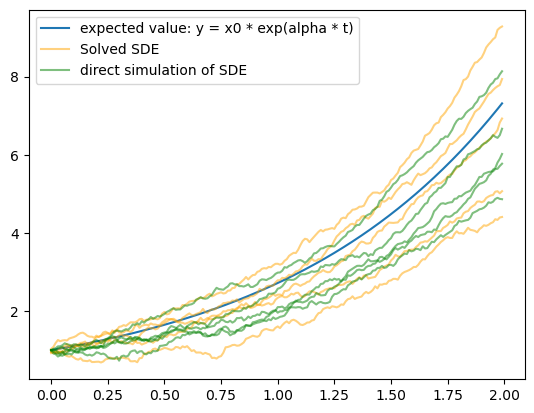

In [205]:
plt.plot(ts, expected, label='expected value: y = x0 * exp(alpha * t)')

# Simulate our solution

for i in range(4):
    integral = sigma * np.exp(-alpha * ts) * np.random.normal(0, np.sqrt(dt), ts.shape[0])
    integral = np.exp(alpha * ts) * np.cumsum(integral)

    soln = expected + integral
    plt.plot(ts, soln, color='orange', alpha=0.5)

integral = sigma * np.exp(-alpha * ts) * np.random.normal(0, np.sqrt(dt), ts.shape[0])
integral = np.exp(alpha * ts) * np.cumsum(integral)

soln = expected + integral
plt.plot(ts, soln, color='orange', alpha=0.5, label='Solved SDE')


# Simulating the SDE directly:
'''
dX = alpha * X * dt + sigma * dW
X[t+dt] - X[t] = alpha * X[t] * dt + sigma * N(0, sqrt(t))
'''
for i in range(4):
    X = np.ones(ts.shape[0]) * x0
    for i in range(1, ts.shape[0]):
        X[i] = X[i-1] + alpha * X[i-1] * dt + sigma * np.random.normal(0, np.sqrt(dt))
    plt.plot(ts, X, color='green', alpha=0.5)

X = np.ones(ts.shape[0]) * x0
for i in range(1, ts.shape[0]):
    X[i] = X[i-1] + alpha * X[i-1] * dt + sigma * np.random.normal(0, np.sqrt(dt))
plt.plot(ts, X, color='green', alpha=0.5, label='direct simulation of SDE')

plt.legend()
plt.show()


Running the code block above many times shows us that the solved SDE and the direct simulation of the SDE appear to be pretty similar.